In [1]:
import os
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import sys
import json
import random
import gc
from copy import deepcopy

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

try:
    import segmentation_models_pytorch as smp
except ImportError as e:
    raise ImportError(
        "segmentation_models_pytorch not installed. Run: "
        "pip install segmentation-models-pytorch"
    ) from e

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
    print(f"GPU: {torch.cuda.get_device_name(0)} | "
          f"Free/Total: {torch.cuda.mem_get_info()[0] / 1e9:.2f} / {torch.cuda.mem_get_info()[1] / 1e9:.2f} GB")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

Using device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU | Free/Total: 6.72 / 8.18 GB


In [2]:
# ---------------------------------------------------------------------
# PATHS — relative to this notebook's location:
#   Segmentation with Annotation/UNET++/spectral_model.ipynb
# ---------------------------------------------------------------------

SPECTRAL_MODULE_DIR = os.path.join("..", "..", "Data Analysis")
IMAGES_DIR = os.path.join("..", "..", "Data Analytics", "Google_MapStaticAPI", "images")

ANNOTATIONS_JSON = os.path.join("..", "..", "Data Analytics", "Annotation", "Solar Images", "annotations", "merged_instances_default.json")
USE_MASK_FOLDER = False
MASKS_DIR = os.path.join("..", "masks")

CHECKPOINT_PATH = os.path.join(".", "outputs", "models", "unet_best.pth")  # already exists — this is what we post-train

OUTPUT_DIR = os.path.join(".", "outputs")
os.makedirs(os.path.join(OUTPUT_DIR, "models"), exist_ok=True)

# Dedicated results folder for this post-training run, kept separate from
# the checkpoints folder so it's obvious what's a model vs. an evaluation artifact
SPECTRAL_RESULTS_DIR = os.path.join(OUTPUT_DIR, "spectral_analysis")
METRICS_DIR = os.path.join(SPECTRAL_RESULTS_DIR, "spectral_metrics")
VIS_DIR = os.path.join(SPECTRAL_RESULTS_DIR, "spectral_visualizations")
os.makedirs(METRICS_DIR, exist_ok=True)
os.makedirs(VIS_DIR, exist_ok=True)

# ---------------------------------------------------------------------
# ARCHITECTURE ASSUMPTIONS — edit here if unet_best.pth was built
# differently. Cell 8 will print what actually loaded so you can verify.
# ---------------------------------------------------------------------
ENCODER_NAME = "resnet34"
ENCODER_WEIGHTS = "imagenet"
NUM_CLASSES = 1

IMG_SIZE = 512
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

# ---------------------------------------------------------------------
# SHADOW-CHANNEL STRATEGY
# ---------------------------------------------------------------------
USE_SHADOW_CHANNEL = True
SHADOW_CHANNEL_INIT_SCALE = 0.1

# ---------------------------------------------------------------------
# FINE-TUNING (POST-TRAINING) HYPERPARAMETERS
# ---------------------------------------------------------------------
BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 2
USE_AMP = True
NUM_EPOCHS = 15
FINE_TUNE_LR = 5e-5
FREEZE_ENCODER_EPOCHS = 3
VAL_SPLIT = 0.15
SHADOW_AUGMENT_PROB = 0.5
SHADOW_LOSS_WEIGHT = 2.0

In [3]:
if SPECTRAL_MODULE_DIR not in sys.path:
    sys.path.append(SPECTRAL_MODULE_DIR)

import spectral_analysis as sa

cfg = sa.SpectralConfig()
print("spectral_analysis module loaded from:", os.path.abspath(SPECTRAL_MODULE_DIR))

if not USE_MASK_FOLDER:
    images_by_id, anns_by_image_id, categories = sa.load_coco_annotations(ANNOTATIONS_JSON)
    all_ids = list(images_by_id.keys())
else:
    image_files = sorted(
        f for f in os.listdir(IMAGES_DIR) if f.lower().endswith((".png", ".jpg", ".jpeg"))
    )
    images_by_id = {i: {"file_name": f, "id": i} for i, f in enumerate(image_files)}
    anns_by_image_id = None
    all_ids = list(images_by_id.keys())

random.shuffle(all_ids)
n_val = max(1, int(len(all_ids) * VAL_SPLIT))
val_ids = all_ids[:n_val]
train_ids = all_ids[n_val:]
print(f"Total annotated images: {len(all_ids)} | train: {len(train_ids)} | val: {len(val_ids)}")


def load_gt_mask_for(image_id, height=None, width=None):
    info = images_by_id[image_id]
    img_path = os.path.join(IMAGES_DIR, info["file_name"])
    rgb = sa.load_image(img_path)
    h, w = rgb.shape[:2]

    if USE_MASK_FOLDER:
        mask_name = os.path.splitext(info["file_name"])[0] + ".png"
        gt_mask = sa.load_mask_folder_annotation(os.path.join(MASKS_DIR, mask_name))
    else:
        gt_mask = sa.ground_truth_mask_for_image(image_id, anns_by_image_id, h, w)

    return rgb, gt_mask

spectral_analysis module loaded from: /mnt/New_Volume/Projects/Solar Detection/Data Analysis
Total annotated images: 2500 | train: 2125 | val: 375


In [4]:
def build_model(in_channels=3):
    return smp.UnetPlusPlus(
        encoder_name=ENCODER_NAME,
        encoder_weights=None,   # weights come from the checkpoint, not ImageNet, at load time
        in_channels=in_channels,
        classes=NUM_CLASSES,
        activation=None,        # we'll apply sigmoid manually (numerically stable with BCEWithLogits)
    )


def inflate_first_conv_to_n_channels(model, n_channels, init_scale=0.1):
    """
    Finds the FIRST nn.Conv2d in model.encoder (architecture-agnostic — works
    for resnet, efficientnet, etc. since it just grabs the stem conv), and
    replaces it with a version that accepts `n_channels` input channels.
    Pretrained RGB filters are copied as-is; new channels are initialised as
    the mean of the RGB filters, scaled down so they start near-silent.
    """
    target_name, target_module, parent_module, attr_name = None, None, None, None

    for name, module in model.encoder.named_modules():
        if isinstance(module, nn.Conv2d):
            target_name, target_module = name, module
            break

    if target_module is None:
        raise RuntimeError("Could not find any Conv2d layer in model.encoder")

    # Walk to the parent module so we can setattr() the replacement in place
    parts = target_name.split(".")
    parent_module = model.encoder
    for p in parts[:-1]:
        parent_module = getattr(parent_module, p)
    attr_name = parts[-1]

    old_conv = target_module
    old_in = old_conv.in_channels
    if old_in == n_channels:
        print(f"First conv already has {n_channels} channels — no change needed.")
        return model

    new_conv = nn.Conv2d(
        in_channels=n_channels,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=(old_conv.bias is not None),
    )

    with torch.no_grad():
        new_conv.weight[:, :old_in, :, :] = old_conv.weight
        extra = n_channels - old_in
        mean_filter = old_conv.weight.mean(dim=1, keepdim=True) * init_scale
        for c in range(extra):
            new_conv.weight[:, old_in + c: old_in + c + 1, :, :] = mean_filter
        if old_conv.bias is not None:
            new_conv.bias[:] = old_conv.bias

    setattr(parent_module, attr_name, new_conv)
    print(f"Inflated '{target_name}': {old_in} -> {n_channels} input channels")
    return model

In [5]:
model = build_model(in_channels=3)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
state_dict = checkpoint.get("model_state_dict", checkpoint) if isinstance(checkpoint, dict) else checkpoint

try:
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    print(f"Loaded checkpoint with {len(missing)} missing / {len(unexpected)} unexpected keys.")
    if missing:
        print("  Missing (first 5):", missing[:5])
    if unexpected:
        print("  Unexpected (first 5):", unexpected[:5])
    if len(missing) > 5 or len(unexpected) > 5:
        print("  ⚠ Large mismatch — architecture assumption in Cell 3 is likely wrong. "
              "Check Model Card.pdf / your training script for the real config.")
except Exception as e:
    print("⚠ Failed to load checkpoint with current architecture assumptions:", e)
    raise

if USE_SHADOW_CHANNEL:
    model = inflate_first_conv_to_n_channels(model, n_channels=4, init_scale=SHADOW_CHANNEL_INIT_SCALE)
    IN_CHANNELS = 4
else:
    IN_CHANNELS = 3

model = model.to(DEVICE)
print("\nEncoder stem (verify this matches your original training setup):")
print(list(model.encoder.named_modules())[0])

Loaded checkpoint with 292 missing / 182 unexpected keys.
  Missing (first 5): ['encoder.conv1.weight', 'encoder.bn1.weight', 'encoder.bn1.bias', 'encoder.bn1.running_mean', 'encoder.bn1.running_var']
  Unexpected (first 5): ['conv0_0.0.block.0.weight', 'conv0_0.0.block.1.weight', 'conv0_0.0.block.1.bias', 'conv0_0.0.block.1.running_mean', 'conv0_0.0.block.1.running_var']
  ⚠ Large mismatch — architecture assumption in Cell 3 is likely wrong. Check Model Card.pdf / your training script for the real config.
Inflated 'conv1': 3 -> 4 input channels

Encoder stem (verify this matches your original training setup):
('', ResNetEncoder(
  (conv1): Conv2d(4, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(6

/tmp/ipykernel_36184/1905870656.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)


In [6]:
def synthetic_shadow_on_panel(rgb, gt_mask, darken=(0.45, 0.75), blue_shift=1.15):
    """Randomly darkens+blue-shifts a small elliptical patch inside gt_mask."""
    ys, xs = np.where(gt_mask == 1)
    if len(ys) == 0:
        return rgb

    idx = np.random.randint(len(ys))
    cy, cx = int(ys[idx]), int(xs[idx])
    h, w = rgb.shape[:2]
    rad_y = np.random.randint(max(4, h // 30), max(6, h // 8))
    rad_x = np.random.randint(max(4, w // 30), max(6, w // 8))

    patch_mask = np.zeros((h, w), dtype=np.uint8)
    cv2.ellipse(patch_mask, (cx, cy), (rad_x, rad_y), 0, 0, 360, 1, thickness=-1)

    out = rgb.astype(np.float32).copy()
    factor = np.random.uniform(*darken)
    out[patch_mask == 1, 0] *= factor
    out[patch_mask == 1, 1] *= factor
    out[patch_mask == 1, 2] *= min(factor * blue_shift, 1.0)
    return np.clip(out, 0, 255).astype(np.uint8)


class SolarShadowDataset(Dataset):
    def __init__(self, sample_ids, images_by_id, anns_by_image_id, images_dir,
                 cfg, img_size, use_shadow_channel=True, augment=False,
                 augment_prob=0.5):
        self.sample_ids = sample_ids
        self.images_by_id = images_by_id
        self.anns_by_image_id = anns_by_image_id
        self.images_dir = images_dir
        self.cfg = cfg
        self.img_size = img_size
        self.use_shadow_channel = use_shadow_channel
        self.augment = augment
        self.augment_prob = augment_prob

    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, idx):
        image_id = self.sample_ids[idx]
        rgb, gt_mask = load_gt_mask_for(image_id)

        rgb = cv2.resize(rgb, (self.img_size, self.img_size), interpolation=cv2.INTER_AREA)
        gt_mask = cv2.resize(gt_mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)

        if self.augment and gt_mask.sum() > 0 and np.random.rand() < self.augment_prob:
            rgb = synthetic_shadow_on_panel(rgb, gt_mask)

        shadow_mask = sa.detect_shadow_mask(rgb, k=self.cfg.shadow_y_k)
        corrected_rgb = (sa.remove_shadow_linear(rgb, shadow_mask)
                          if shadow_mask.sum() > 0 else rgb)

        rgb_norm = (corrected_rgb.astype(np.float32) / 255.0 - IMAGENET_MEAN) / IMAGENET_STD

        if self.use_shadow_channel:
            stacked = np.dstack([rgb_norm, shadow_mask.astype(np.float32)])
        else:
            stacked = rgb_norm

        image_tensor = torch.from_numpy(stacked.transpose(2, 0, 1)).float()
        mask_tensor = torch.from_numpy(gt_mask.astype(np.float32)).unsqueeze(0)
        shadow_tensor = torch.from_numpy(shadow_mask.astype(np.float32)).unsqueeze(0)

        return image_tensor, mask_tensor, shadow_tensor

In [7]:
train_ds = SolarShadowDataset(
    train_ids, images_by_id, anns_by_image_id, IMAGES_DIR, cfg, IMG_SIZE,
    use_shadow_channel=USE_SHADOW_CHANNEL, augment=True, augment_prob=SHADOW_AUGMENT_PROB,
)
val_ds = SolarShadowDataset(
    val_ids, images_by_id, anns_by_image_id, IMAGES_DIR, cfg, IMG_SIZE,
    use_shadow_channel=USE_SHADOW_CHANNEL, augment=False,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 531 | Val batches: 94


In [8]:
def dice_loss(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    intersection = (probs * targets).sum(dim=1)
    union = probs.sum(dim=1) + targets.sum(dim=1)
    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice.mean()


def shadow_weighted_loss(logits, targets, shadow_mask, shadow_weight=2.0):
    weight_map = 1.0 + shadow_mask * (shadow_weight - 1.0)
    bce = F.binary_cross_entropy_with_logits(logits, targets, weight=weight_map, reduction="mean")
    dsc = dice_loss(logits, targets)
    return bce + dsc

In [9]:
def set_encoder_trainable(model, trainable):
    for p in model.encoder.parameters():
        p.requires_grad = trainable


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_iou, total_f1, n = 0.0, 0.0, 0
    for images, masks, _ in loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(images)
        preds = (torch.sigmoid(logits) > 0.5).float()

        for i in range(preds.size(0)):
            p = preds[i, 0].cpu().numpy().astype(np.uint8)
            g = masks[i, 0].cpu().numpy().astype(np.uint8)
            total_iou += sa.compute_iou(p, g)
            total_f1 += sa.compute_precision_recall_f1(p, g)["f1"]
            n += 1
        del images, masks, logits, preds

    torch.cuda.empty_cache()
    model.train()
    return total_iou / max(n, 1), total_f1 / max(n, 1)


optimizer = torch.optim.Adam(model.parameters(), lr=FINE_TUNE_LR)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
best_val_iou = -1.0
history = []

for epoch in range(1, NUM_EPOCHS + 1):
    set_encoder_trainable(model, trainable=(epoch > FREEZE_ENCODER_EPOCHS))
    model.train()
    running_loss = 0.0
    optimizer.zero_grad()

    for step, (images, masks, shadow_masks) in enumerate(
        tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS}")
    ):
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        shadow_masks = shadow_masks.to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(images)
            loss = shadow_weighted_loss(logits, masks, shadow_masks, shadow_weight=SHADOW_LOSS_WEIGHT)
            loss = loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()

        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        running_loss += loss.item() * GRAD_ACCUM_STEPS
        del images, masks, shadow_masks, logits, loss

    if len(train_loader) % GRAD_ACCUM_STEPS != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

    torch.cuda.empty_cache()
    gc.collect()

    val_iou, val_f1 = evaluate(model, val_loader)
    avg_loss = running_loss / len(train_loader)
    history.append({"epoch": epoch, "train_loss": avg_loss, "val_iou": val_iou, "val_f1": val_f1})
    print(f"Epoch {epoch:2d} | loss={avg_loss:.4f} | val_IoU={val_iou:.4f} | val_F1={val_f1:.4f}")

    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save(
            {"model_state_dict": model.state_dict(), "in_channels": IN_CHANNELS, "val_iou": val_iou},
            os.path.join(OUTPUT_DIR, "models", "unet_best_spectral.pth"),
        )
        print(f"  ↳ saved new best (val_IoU={val_iou:.4f})")

pd.DataFrame(history).to_csv(os.path.join(METRICS_DIR, "training_history.csv"), index=False)

/tmp/ipykernel_36184/3526213601.py:30: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


Epoch 1/15:   0%|          | 0/531 [00:00<?, ?it/s]

/tmp/ipykernel_36184/3526213601.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_36184/3526213601.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch  1 | loss=1.1009 | val_IoU=0.4414 | val_F1=0.5985
  ↳ saved new best (val_IoU=0.4414)


Epoch 2/15:   0%|          | 0/531 [00:00<?, ?it/s]

...

Epoch 13 | loss=0.2717 | val_IoU=0.5871 | val_F1=0.7266


Epoch 14/15:   0%|          | 0/531 [00:00<?, ?it/s]

Epoch 14 | loss=0.2544 | val_IoU=0.5667 | val_F1=0.7117


Epoch 15/15:   0%|          | 0/531 [00:00<?, ?it/s]

Epoch 15 | loss=0.2459 | val_IoU=0.5936 | val_F1=0.7328


In [10]:
@torch.no_grad()
def stratified_evaluate(model, dataset):
    model.eval()
    rows = []
    for i in range(len(dataset)):
        image, mask, shadow = dataset[i]
        logits = model(image.unsqueeze(0).to(DEVICE))
        pred = (torch.sigmoid(logits) > 0.5).float()[0, 0].cpu().numpy().astype(np.uint8)

        g = mask[0].numpy().astype(np.uint8)
        s = shadow[0].numpy().astype(np.uint8)

        overall_iou = sa.compute_iou(pred, g)
        overall_prf = sa.compute_precision_recall_f1(pred, g)

        shadow_panel = np.logical_and(s == 1, g == 1)
        shadow_roof = np.logical_and(s == 1, g == 0)

        def masked_recall(region):
            if region.sum() == 0:
                return np.nan
            tp = np.logical_and(pred == 1, region).sum()
            return tp / region.sum()

        rows.append({
            "sample_id": dataset.sample_ids[i],
            "overall_iou": overall_iou,
            "overall_f1": overall_prf["f1"],
            "shadow_over_panel_recall": masked_recall(shadow_panel),
            "shadow_over_roof_fp_rate": (
                np.logical_and(pred == 1, shadow_roof).sum() / max(shadow_roof.sum(), 1)
            ),
            "shadow_coverage_pct": 100.0 * s.sum() / s.size,
        })
    model.train()
    return pd.DataFrame(rows)


spectral_results = stratified_evaluate(model, val_ds)
spectral_results.to_csv(os.path.join(METRICS_DIR, "spectral_model_stratified.csv"), index=False)
spectral_results[["overall_iou", "overall_f1", "shadow_over_panel_recall", "shadow_over_roof_fp_rate"]].mean()

overall_iou                 0.593567
overall_f1                  0.732760
shadow_over_panel_recall    0.282308
shadow_over_roof_fp_rate    0.002583
dtype: float64

In [11]:
baseline_model = build_model(in_channels=3)
baseline_ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
baseline_state = baseline_ckpt.get("model_state_dict", baseline_ckpt) if isinstance(baseline_ckpt, dict) else baseline_ckpt
baseline_model.load_state_dict(baseline_state, strict=False)
baseline_model = baseline_model.to(DEVICE).eval()

baseline_val_ds = SolarShadowDataset(
    val_ids, images_by_id, anns_by_image_id, IMAGES_DIR, cfg, IMG_SIZE,
    use_shadow_channel=False, augment=False,
)

baseline_results = stratified_evaluate(baseline_model, baseline_val_ds)
baseline_results.to_csv(os.path.join(METRICS_DIR, "baseline_stratified.csv"), index=False)

comparison = pd.DataFrame({
    "baseline (original)": baseline_results[
        ["overall_iou", "overall_f1", "shadow_over_panel_recall", "shadow_over_roof_fp_rate"]
    ].mean(),
    "spectral + shadow fine-tuned": spectral_results[
        ["overall_iou", "overall_f1", "shadow_over_panel_recall", "shadow_over_roof_fp_rate"]
    ].mean(),
})
comparison["delta"] = comparison["spectral + shadow fine-tuned"] - comparison["baseline (original)"]
comparison.to_csv(os.path.join(METRICS_DIR, "baseline_vs_spectral_comparison.csv"))
comparison

/tmp/ipykernel_36184/392186132.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  baseline_ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)


,baseline (original),spectral + shadow fine-tuned,delta
overall_iou,0.053971,0.593567,0.539596
overall_f1,0.100102,0.732760,0.632658
shadow_over_panel_recall,0.900794,0.282308,-0.618486
shadow_over_roof_fp_rate,0.864682,0.002583,-0.862099


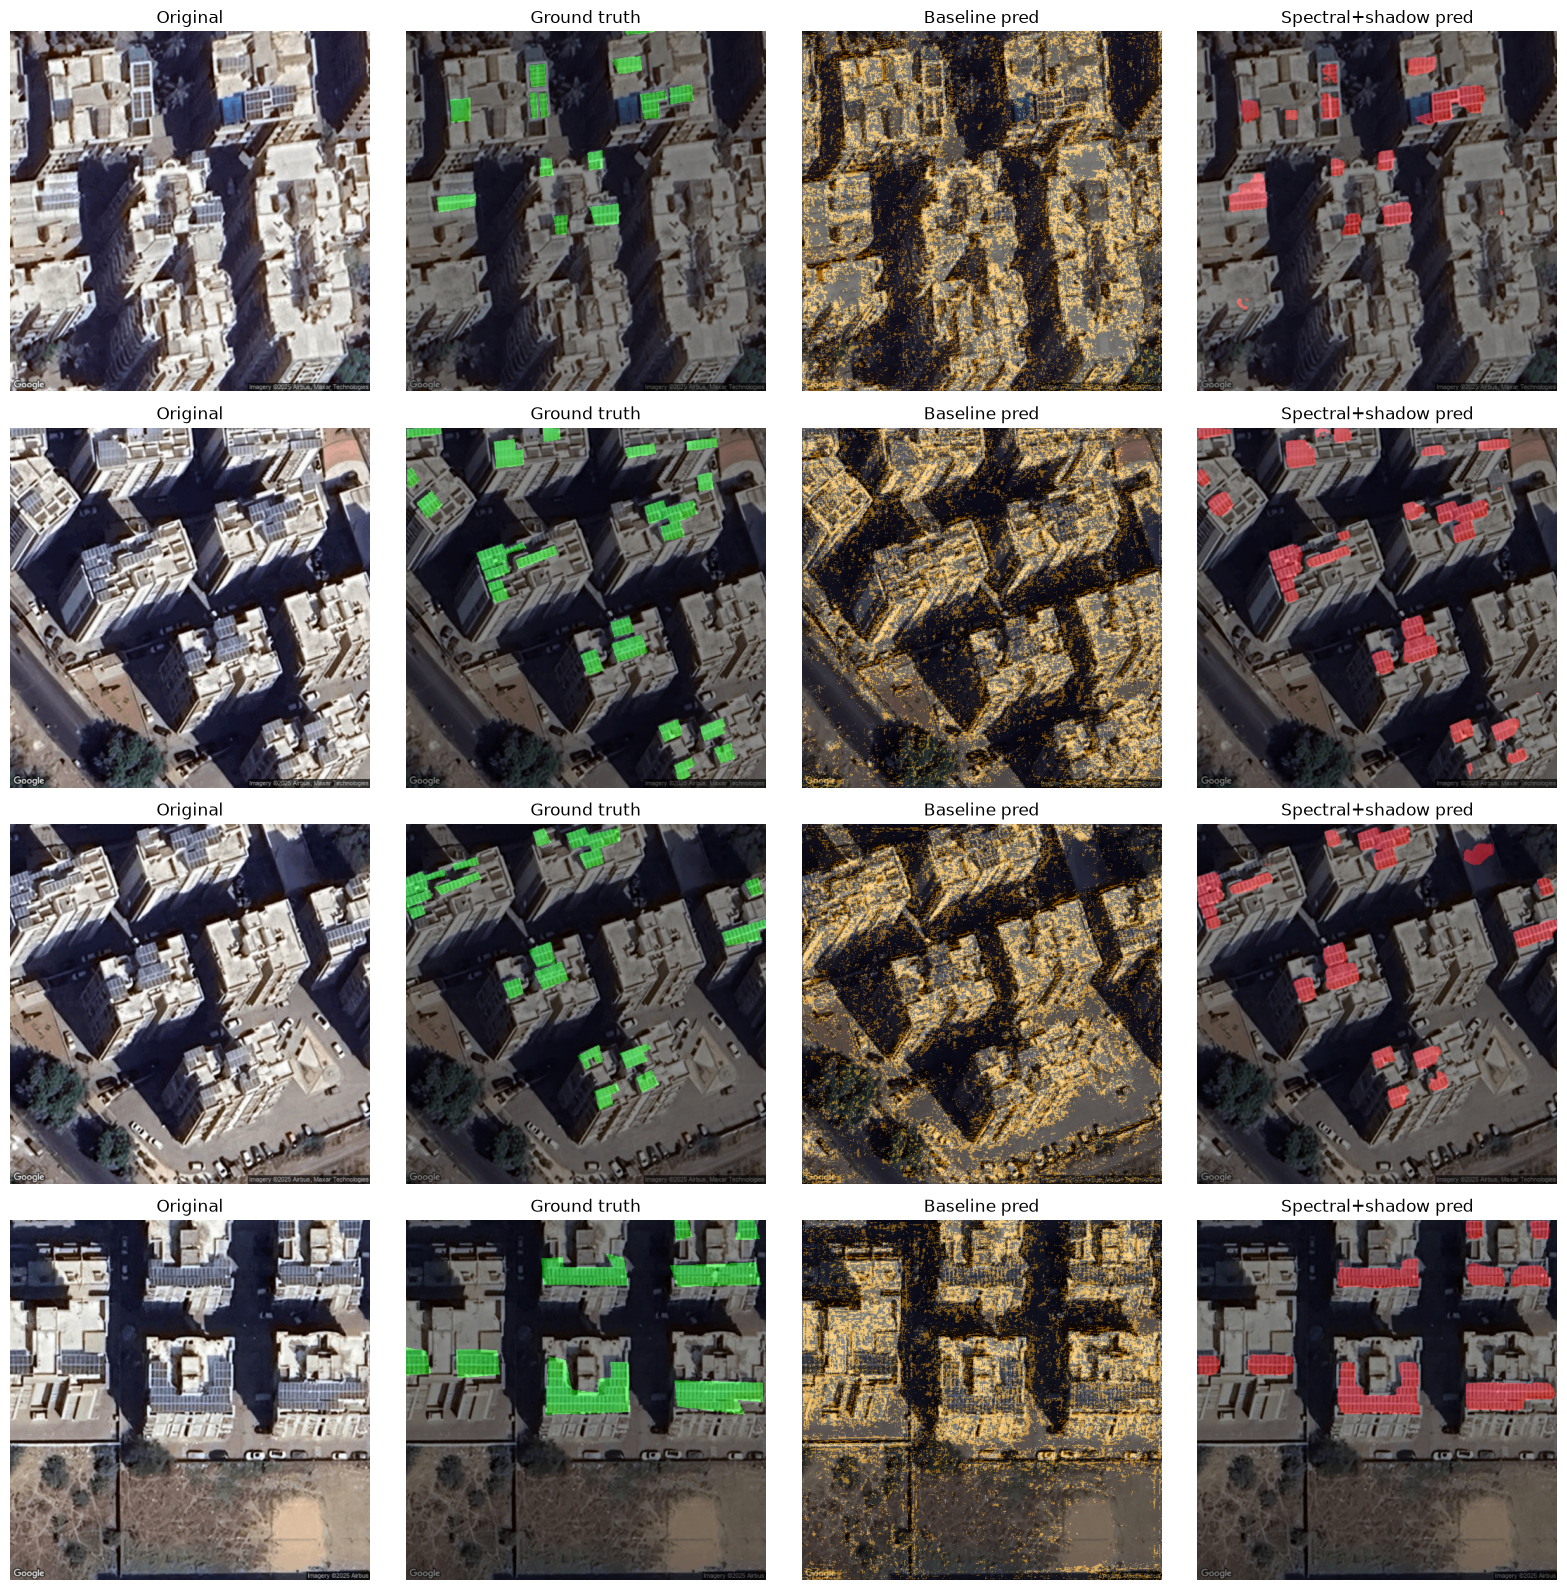

In [12]:
shadow_heavy = spectral_results.sort_values("shadow_coverage_pct", ascending=False).head(4)

fig, axes = plt.subplots(len(shadow_heavy), 4, figsize=(16, 4 * len(shadow_heavy)))
for row_i, (_, row) in enumerate(shadow_heavy.iterrows()):
    idx = val_ds.sample_ids.index(row["sample_id"])
    image, mask, shadow = val_ds[idx]
    baseline_image, _, _ = baseline_val_ds[idx]

    with torch.no_grad():
        pred_spectral = (torch.sigmoid(model(image.unsqueeze(0).to(DEVICE))) > 0.5).float()[0, 0].cpu().numpy()
        pred_baseline = (torch.sigmoid(baseline_model(baseline_image.unsqueeze(0).to(DEVICE))) > 0.5).float()[0, 0].cpu().numpy()

    rgb_i, gt_i = load_gt_mask_for(row["sample_id"])
    rgb_i = cv2.resize(rgb_i, (IMG_SIZE, IMG_SIZE))

    axes[row_i, 0].imshow(rgb_i); axes[row_i, 0].set_title("Original"); axes[row_i, 0].axis("off")
    axes[row_i, 1].imshow(sa.overlay_mask(rgb_i, mask[0].numpy().astype(np.uint8), (0, 255, 0))); axes[row_i, 1].set_title("Ground truth"); axes[row_i, 1].axis("off")
    axes[row_i, 2].imshow(sa.overlay_mask(rgb_i, pred_baseline.astype(np.uint8), (255, 165, 0))); axes[row_i, 2].set_title("Baseline pred"); axes[row_i, 2].axis("off")
    axes[row_i, 3].imshow(sa.overlay_mask(rgb_i, pred_spectral.astype(np.uint8), (255, 0, 0))); axes[row_i, 3].set_title("Spectral+shadow pred"); axes[row_i, 3].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "shadow_heavy_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()